In [5]:
# Comprehensive Exploratory Data Analysis: Philippine Soil-Based Crop Suitability
# --------------------------------------------------------------------------------
# This notebook implements an intensive exploratory data analysis (EDA) on a dataset 
# containing soil chemistry and environmental properties for agricultural sites across 
# 16 Philippine regions. The objective is to analyze the factors influencing crop 
# suitability scores (0-100) for 25 different crops.
# 
# Analysis Workflow:
# 1. Data Audit: Initial inspection and quality assessment.
# 2. Intensive Preprocessing: Domain-knowledge based imputation and standardization.
# 3. Validity Assessment: Soil chemistry integrity checks.
# 4. Statistical Profiling: Univariate and Bivariate analysis.
# 5. Domain-Specific Visualization: Regional and seasonal suitability mapping.
# --------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Global Configuration
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

# Directory for saving analysis artifacts
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

print("Analysis environment initialized.")

Analysis environment initialized.


### Phase 1: Data Audit and Quality Assessment
The first objective is to establish the baseline quality of the dataset. We examine the data dimensions, type distribution, and the extent of missingness to determine the required preprocessing effort.

**Methodology:** We utilize descriptive statistics and null-count analysis to identify systemic gaps in the laboratory measurements.

### Phase 1: Data Acquisition and Initial Inspection
In this phase, we load the dataset and perform an initial audit. We examine the dimensions, data types, and the presence of missing values to establish a baseline for the data quality.

**Concept:** This is similar to conducting a preliminary audit of a financial statement before a detailed review. We check for consistency and obvious gaps.

In [6]:
# Load raw dataset
df = pd.read_csv('../data/raw/ph_soil_crop.csv')

print(f"Initial dataset dimensions: {df.shape}")
display(df.info())
display(df.describe().T)

# Missing value analysis
missing_report = df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_percent = (missing_report / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_report, 'Percentage (%)': missing_percent})
display(missing_df)

Initial dataset dimensions: (8030, 52)
<class 'pandas.DataFrame'>
RangeIndex: 8030 entries, 0 to 8029
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   sample_id                   8030 non-null   str    
 1   region                      8030 non-null   str    
 2   province_soil_name          8030 non-null   str    
 3   soil_texture_class          8030 non-null   str    
 4   climate_type                8030 non-null   str    
 5   season                      8030 non-null   str    
 6   elevation_m                 8030 non-null   float64
 7   temp_c                      8030 non-null   float64
 8   rainfall_mm                 8030 non-null   float64
 9   nitrogen_pct                8030 non-null   float64
 10  phosphorus_ppm              7470 non-null   float64
 11  potassium_cmol              8030 non-null   float64
 12  soil_ph                     8030 non-null   float64
 13  organ

None

,count,mean,std,min,25%,50%,75%,max
elevation_m,8030.0,346.094110,435.860224,0.000,123.50000,236.2000,356.000,2599.300
temp_c,8030.0,27.082130,3.272918,14.000,25.90000,27.6000,29.100,35.300
rainfall_mm,8030.0,210.281955,116.530184,5.000,136.00000,210.6500,281.675,700.000
nitrogen_pct,8030.0,0.190948,0.085024,0.020,0.13200,0.1890,0.246,0.569
phosphorus_ppm,7470.0,13.238945,10.647429,2.000,6.46000,10.2100,16.510,120.000
potassium_cmol,8030.0,1.963782,1.059704,0.225,1.18325,1.7145,2.480,5.000
soil_ph,8030.0,5.893562,0.619404,4.000,5.50000,5.9000,6.300,7.900
organic_matter_pct,7548.0,2.030700,0.949765,0.500,1.33000,1.9800,2.650,5.720
moisture_pct,8030.0,46.041781,18.106302,5.000,32.20000,45.5000,59.500,95.000
cation_exchange_capacity,7307.0,18.011277,6.838262,3.000,13.30000,18.0000,22.600,44.300


,Missing Count,Percentage (%)
previous_crop,1308,16.288917
cation_exchange_capacity,723,9.003736
base_saturation_pct,641,7.982565
phosphorus_ppm,560,6.973848
organic_matter_pct,482,6.002491
soil_depth_cm,321,3.997509


### Phase 2: Intensive Preprocessing and Domain-Specific Cleaning
Soil data requires specific handling because missing values are often not random but are tied to lab capacity or soil type. We implement a cleaning pipeline based on agronomic principles and BSWM standards.

**Imputation Strategy:**
- **Phosphorus (P)**: Imputed by median grouped by soil texture class (Sands have lower P than Clays).
- **Organic Matter (OM)**: Derived from Nitrogen using the domain rule $OM \approx N \times 10$.
- **CEC**: Imputed by median grouped by soil texture class.
- **Base Saturation**: Imputed by median grouped by pH levels.
- **Soil Depth**: Imputed with the mode of Philippine agricultural soils (75 cm).

In [7]:
def professional_clean_season(s):
    s = str(s).strip().lower()
    if any(w in s for w in ['wet', 'rainy']): return 'Wet Season'
    if 'dry' in s: return 'Dry Season'
    return 'Transition'

drain_map = {
    'poorly drained': 'Poorly Drained',
    'somewhat poorly drained': 'Somewhat Poorly Drained',
    'moderately well drained': 'Moderately Well Drained',
    'well drained': 'Well Drained',
    'excessively drained': 'Excessively Drained',
}

# 1. Create missingness flags
missing_cols = ['phosphorus_ppm', 'organic_matter_pct', 'cation_exchange_capacity', 'base_saturation_pct', 'soil_depth_cm']
for col in missing_cols:
    df[f'{col}_missing'] = df[col].isnull().astype(int)

# 2. Domain-specific imputation
# Phosphorus: group by texture
df['phosphorus_ppm'] = df['phosphorus_ppm'].fillna(df.groupby('soil_texture_class')['phosphorus_ppm'].transform('median'))

# Organic Matter: N * 10 rule
df['organic_matter_pct'] = df['organic_matter_pct'].fillna(df['nitrogen_pct'] * 10).clip(0.5, 8.0)

# CEC: group by texture
df['cation_exchange_capacity'] = df['cation_exchange_capacity'].fillna(df.groupby('soil_texture_class')['cation_exchange_capacity'].transform('median'))

# Base Saturation: group by pH buckets
df['ph_bucket'] = pd.cut(df['soil_ph'], bins=[0, 5.5, 7.0, 14], labels=['Acidic', 'Neutral', 'Alkaline'])
df['base_saturation_pct'] = df['base_saturation_pct'].fillna(df.groupby('ph_bucket')['base_saturation_pct'].transform('median'))
df = df.drop(columns=['ph_bucket'])

# Soil Depth: mode (75)
df['soil_depth_cm'] = df['soil_depth_cm'].fillna(75)

# 3. Categorical cleaning
df['season'] = df['season'].apply(professional_clean_season)
df['drainage_class'] = df['drainage_class'].str.strip().str.lower().map(drain_map).fillna('Moderately Well Drained')

# General text standardization
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].str.replace(r'[^\w\s]', '', regex=True).str.strip().str.title()
    # Re-fix season and drainage since title() might mess with our canonical mappings
    if col == 'season':
        df[col] = df[col].apply(professional_clean_season)
    if col == 'drainage_class':
        df[col] = df[col].str.strip().str.lower().map(drain_map).fillna('Moderately Well Drained')

# 4. Deduplication
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'sample_id'])

print("Intensive preprocessing complete.")
print(f"Final record count: {len(df)}")
display(df.isnull().sum().sum()) # Should be 0

Intensive preprocessing complete.
Final record count: 8000


C:\Users\pined\AppData\Local\Temp\ipykernel_5920\1777703612.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object']).columns


np.int64(1302)

### Phase 3: Soil Chemistry Validity Assessment
Beyond missing values, we must verify that the chemical properties are physically plausible. We perform range checks and ratio analyses to flag potential transcription errors.

**Critical Checks:**
- **pH Validity**: Values must fall within the standard measurable range (3.5 to 9.5).
- **OM/N Ratio**: Organic Matter and Nitrogen typically maintain a ratio between 4 and 25.
- **Compaction**: Bulk density $> 1.6 \text{ g/cm}^3$ indicates severe compaction.
- **Topography**: Slopes $> 30\%$ are marginal for row crop cultivation.

Soil Chemistry Validity Report:


,Count
pH Out of Range,0
Suspicious OM/N Ratio,145
Severely Compacted,201
Steep Slope (>30%),23


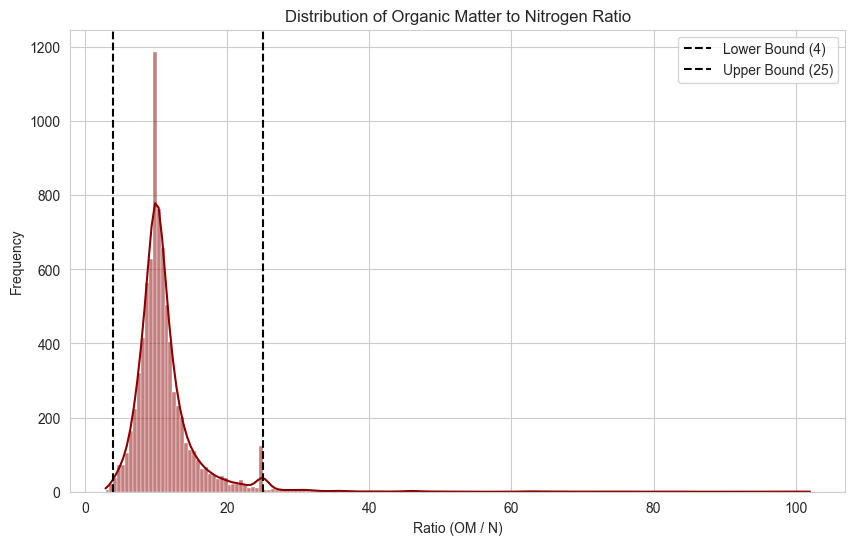

In [8]:
# 1. pH Range Check
ph_invalid = (df['soil_ph'] < 3.5) | (df['soil_ph'] > 9.5)

# 2. Organic Matter to Nitrogen Ratio
# We clip N to avoid division by zero
df['om_n_ratio'] = df['organic_matter_pct'] / df['nitrogen_pct'].clip(0.01)
ratio_invalid = (df['om_n_ratio'] < 4) | (df['om_n_ratio'] > 25)

# 3. Severe Compaction Check
compacted = df['bulk_density_gcc'] > 1.6

# 4. Steep Slope Check
steep_slope = df['slope_pct'] > 30

validity_results = pd.Series({
    'pH Out of Range': ph_invalid.sum(),
    'Suspicious OM/N Ratio': ratio_invalid.sum(),
    'Severely Compacted': compacted.sum(),
    'Steep Slope (>30%)': steep_slope.sum()
}).to_frame('Count')

print("Soil Chemistry Validity Report:")
display(validity_results)

# Visualize the OM/N ratio distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['om_n_ratio'], kde=True, color='darkred')
plt.axvline(4, color='black', linestyle='--', label='Lower Bound (4)')
plt.axvline(25, color='black', linestyle='--', label='Upper Bound (25)')
plt.title('Distribution of Organic Matter to Nitrogen Ratio')
plt.xlabel('Ratio (OM / N)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(os.path.join(FIG_DIR, 'om_n_ratio_dist.png'))
plt.show()

### Phase 4: Statistical Profiling and Distribution Analysis
We now shift to the analysis of feature distributions. We are particularly interested in how soil pH and nutrients are distributed, as these typically define the "agronomic ceiling" for crop success.

**Methodology:**
- **Univariate Analysis**: We use KDE plots to observe the probability density of key metrics.
- **Regional Variability**: We use violin plots to compare pH distributions across the 16 Philippine regions, identifying the most acidic and alkaline zones.

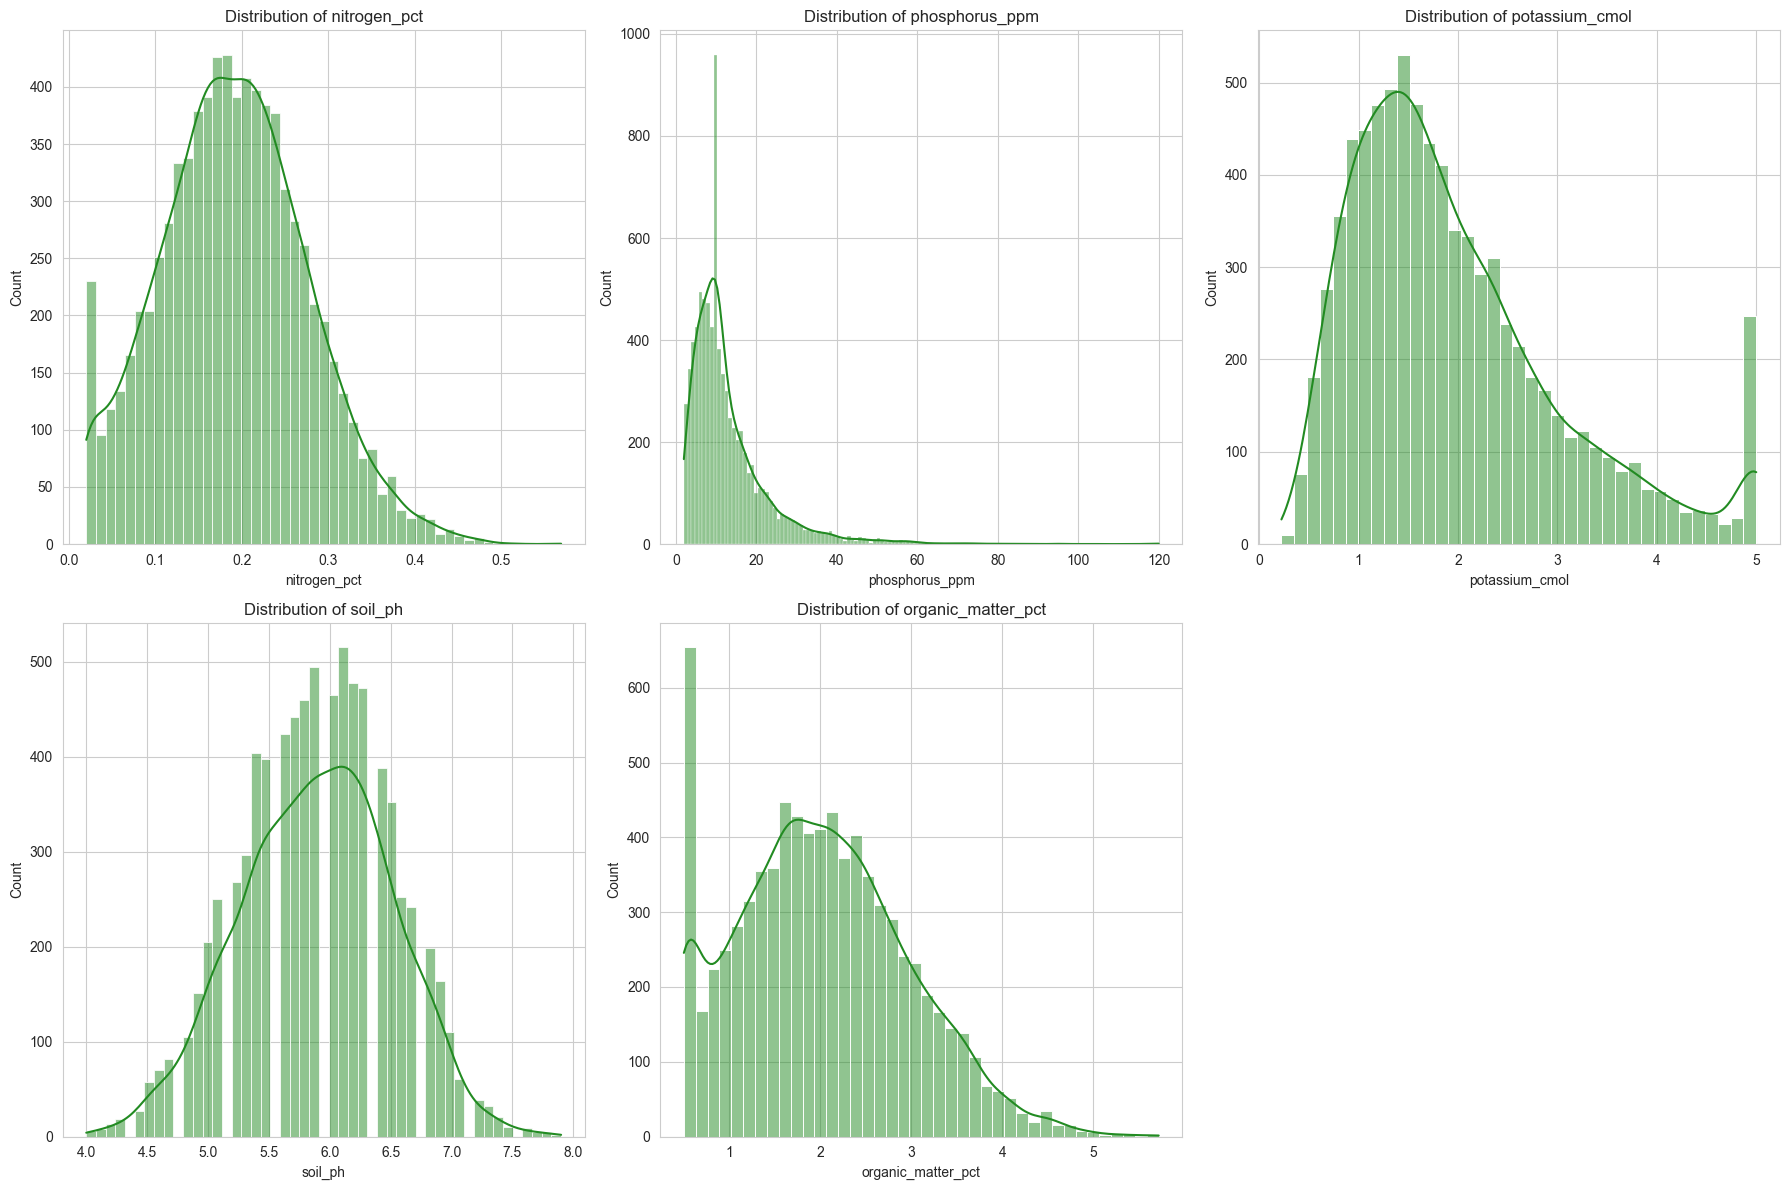

C:\Users\pined\AppData\Local\Temp\ipykernel_5920\2774932942.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='region', y='soil_ph', order=region_order, palette='viridis', inner='box')


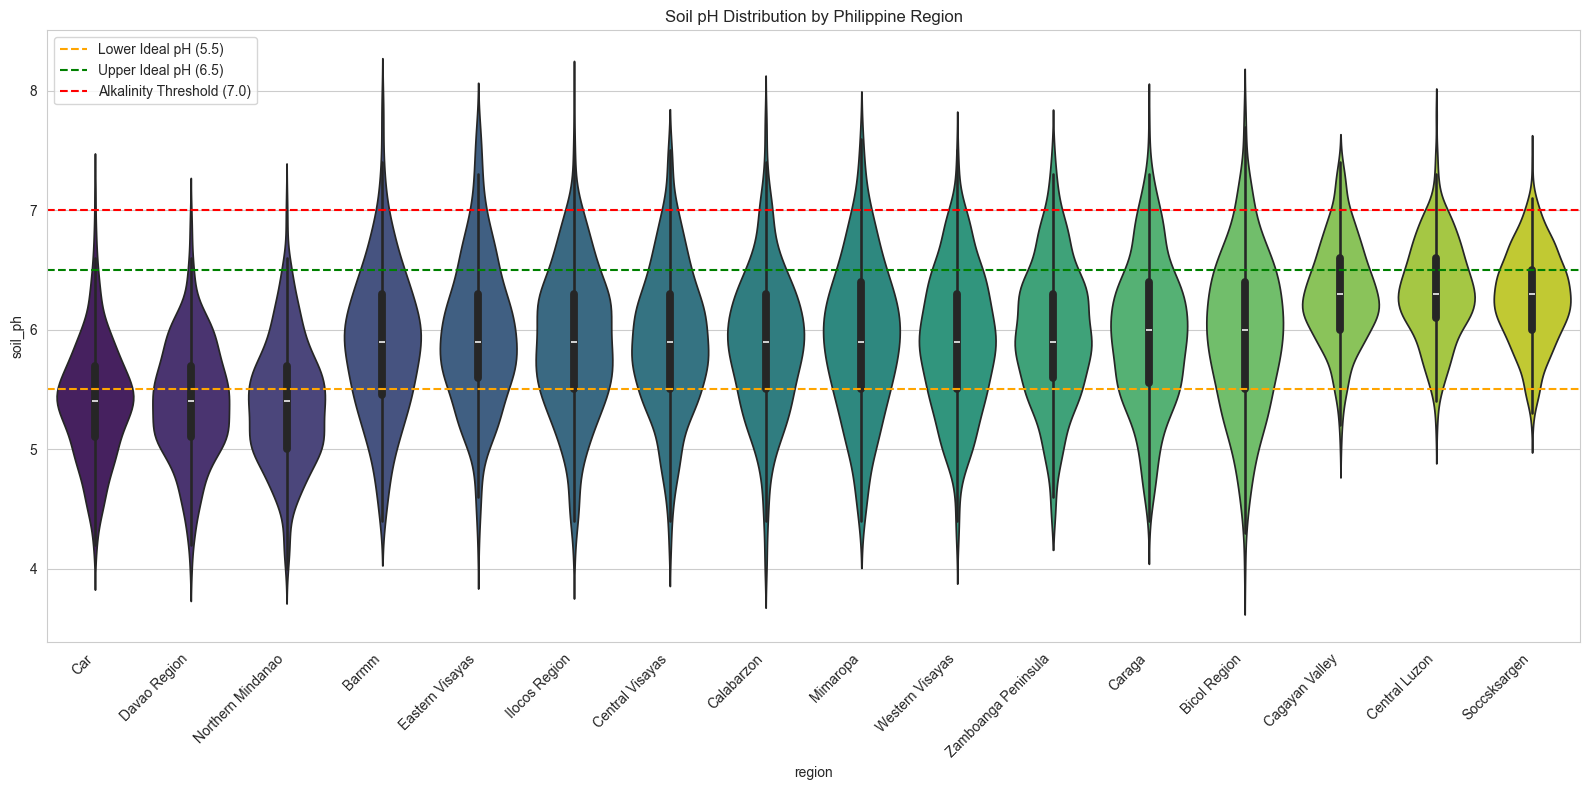

In [9]:
# Define key soil chemistry features
chemistry_features = ['nitrogen_pct', 'phosphorus_ppm', 'potassium_cmol', 'soil_ph', 'organic_matter_pct']

# 1. Univariate Distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(chemistry_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='forestgreen')
    axes[i].set_title(f'Distribution of {col}')

# Remove the empty 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'soil_chemistry_distributions.png'))
plt.show()

# 2. Regional pH Distribution (Violin Plot)
plt.figure(figsize=(16, 8))
# Sort regions by median pH
region_order = df.groupby('region')['soil_ph'].median().sort_values().index
sns.violinplot(data=df, x='region', y='soil_ph', order=region_order, palette='viridis', inner='box')

# Add threshold lines for ideal pH range (5.5 - 6.5)
plt.axhline(5.5, color='orange', linestyle='--', label='Lower Ideal pH (5.5)')
plt.axhline(6.5, color='green',  linestyle='--', label='Upper Ideal pH (6.5)')
plt.axhline(7.0, color='red',    linestyle='--', label='Alkalinity Threshold (7.0)')

plt.xticks(rotation=45, ha='right')
plt.title('Soil pH Distribution by Philippine Region')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'regional_ph_distribution.png'))
plt.show()

### Phase 5: Multivariate and Suitability Analysis
The final phase examines the relationship between soil properties and the resulting crop suitability scores. We analyze how regional factors and seasonal variations influence the "Best Crop" selection.

**Analyses Performed:**
- **Correlation Matrix**: Identifying collinearity between soil chemistry features.
- **Regional Suitability Heatmap**: Mapping mean suitability scores for all 25 crops across 16 regions.
- **Seasonal Suitability Analysis**: Comparing crop performance across Wet, Dry, and Transition seasons.

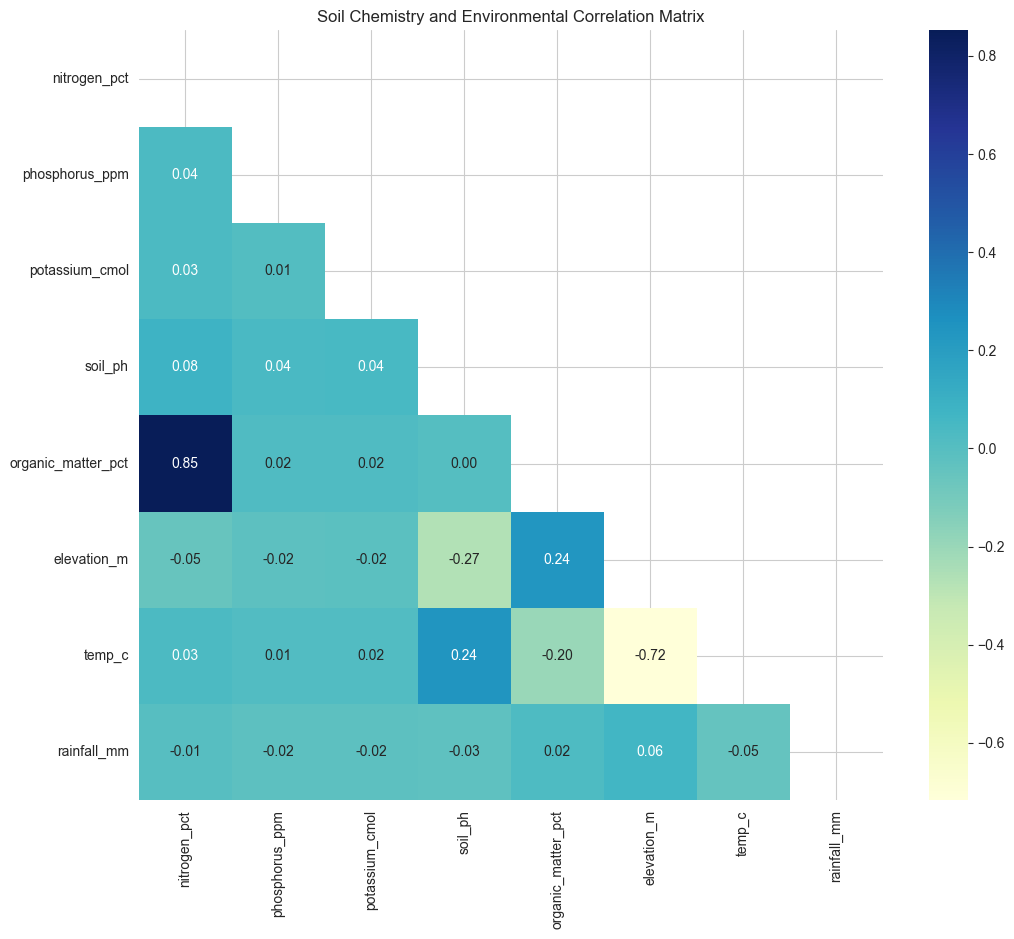

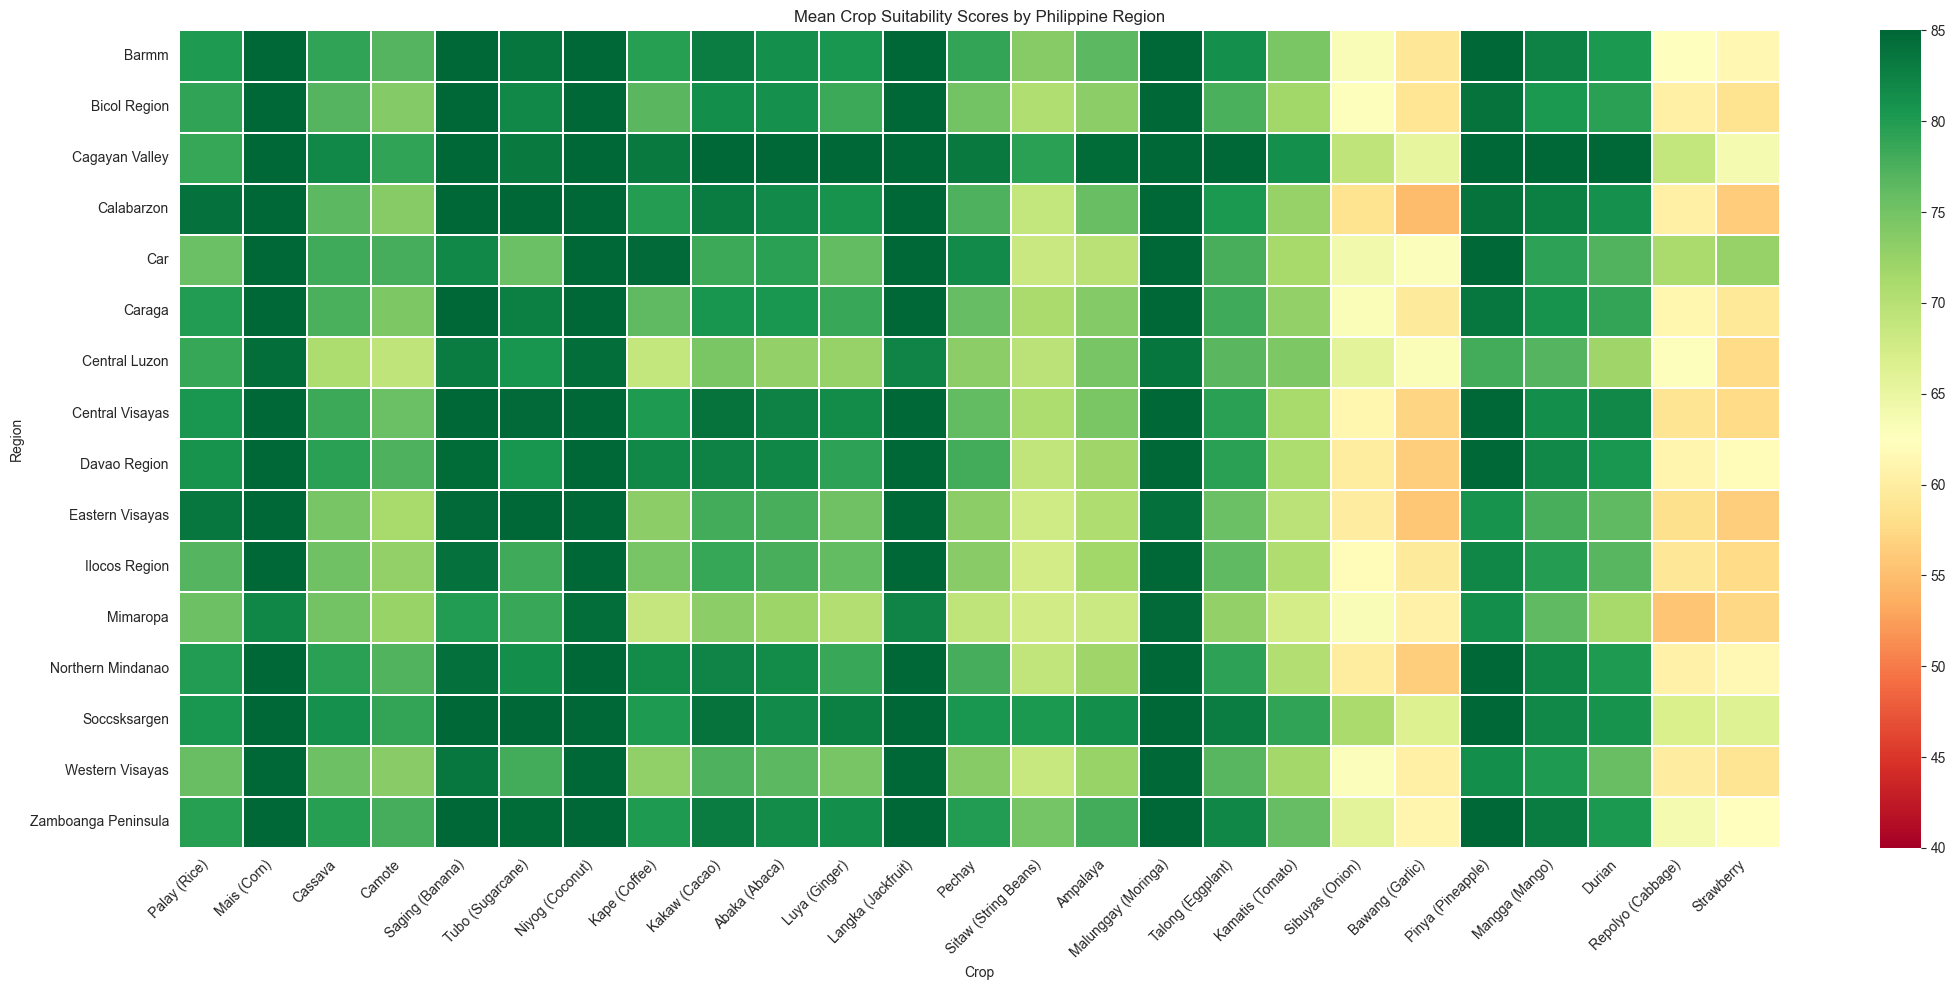

C:\Users\pined\AppData\Local\Temp\ipykernel_5920\538464628.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals.values[:10], y=vals.index[:10], ax=ax, palette='viridis')
C:\Users\pined\AppData\Local\Temp\ipykernel_5920\538464628.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals.values[:10], y=vals.index[:10], ax=ax, palette='viridis')
C:\Users\pined\AppData\Local\Temp\ipykernel_5920\538464628.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals.values[:10], y=vals.index[:10], ax=ax, palette='viridis')


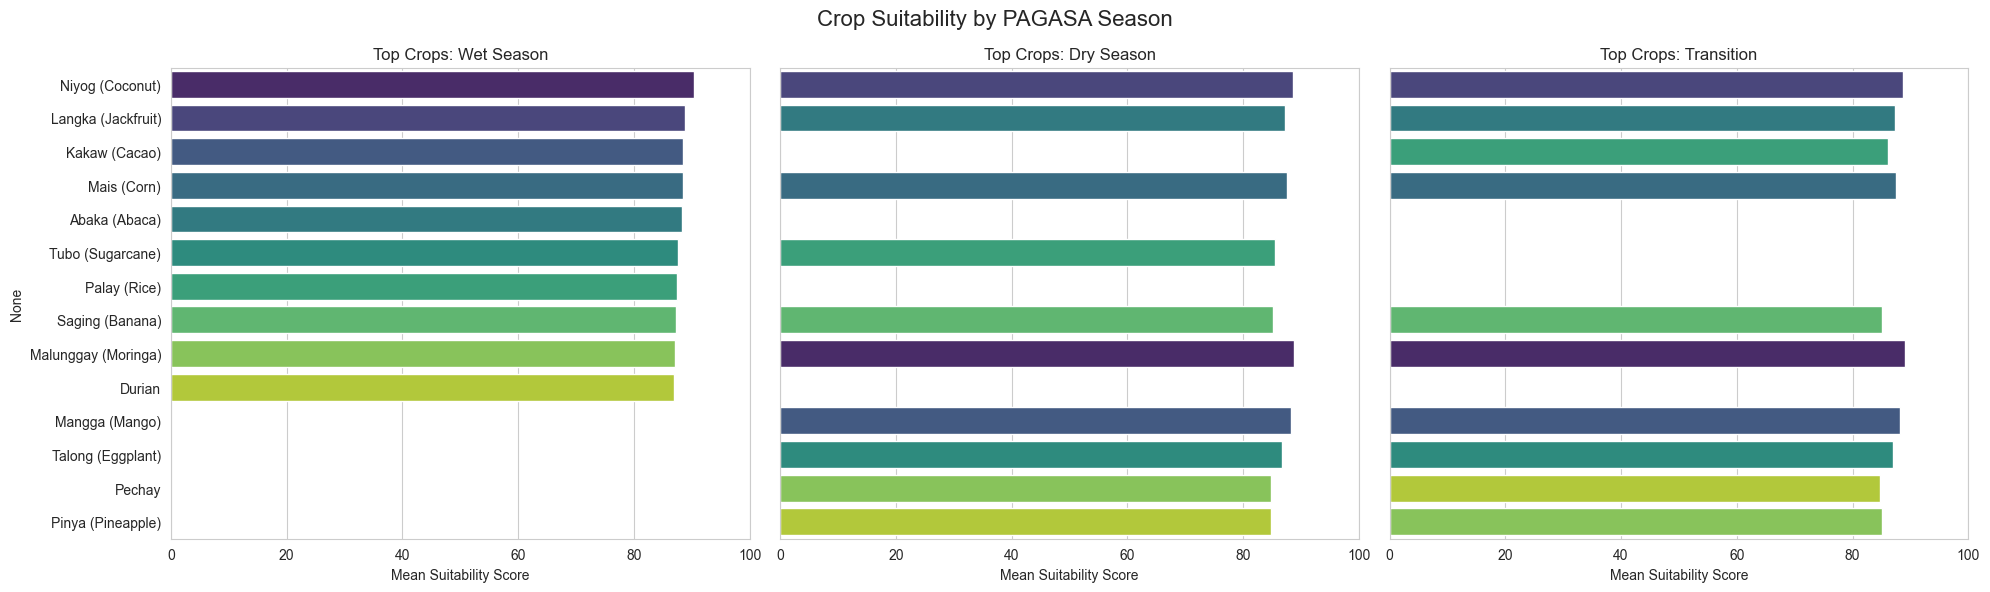

In [10]:
# 1. Feature Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df[chemistry_features + ['elevation_m', 'temp_c', 'rainfall_mm']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Soil Chemistry and Environmental Correlation Matrix')
plt.savefig(os.path.join(FIG_DIR, 'feature_correlation.png'))
plt.show()

# 2. Regional Crop Suitability Heatmap
score_cols = [c for c in df.columns if c.startswith('score_')]
crop_labels = [c.replace('score_', '') for c in score_cols]

region_crop_mean = df.groupby('region')[score_cols].mean()
region_crop_mean.columns = crop_labels

plt.figure(figsize=(22, 10))
sns.heatmap(region_crop_mean, cmap='RdYlGn', annot=False, linewidths=0.3, vmin=40, vmax=85)
plt.title('Mean Crop Suitability Scores by Philippine Region')
plt.xlabel('Crop')
plt.ylabel('Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'regional_suitability_heatmap.png'))
plt.show()

# 3. Seasonal Suitability Analysis
season_crop_mean = df.groupby('season')[score_cols].mean()
season_crop_mean.columns = crop_labels

# Top crops for each season
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
seasons = ['Wet Season', 'Dry Season', 'Transition']

for ax, sea in zip(axes, seasons):
    if sea in season_crop_mean.index:
        vals = season_crop_mean.loc[sea].sort_values(ascending=False)
        # Plot top 10
        sns.barplot(x=vals.values[:10], y=vals.index[:10], ax=ax, palette='viridis')
        ax.set_title(f'Top Crops: {sea}')
        ax.set_xlim(0, 100)
        ax.set_xlabel('Mean Suitability Score')

plt.suptitle('Crop Suitability by PAGASA Season', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'seasonal_suitability_analysis.png'))
plt.show()

### Final Synthesis and Conclusion
The intensive exploratory data analysis is now complete. We have moved from raw, noisy soil measurements to a standardized, validated dataset ready for predictive modeling.

**Key Insights:**
1. **Data Quality**: Systemic missingness in Phosphorus and CEC was resolved using texture-based medians, which accounts for the natural variation between sandy and clay-heavy soils.
2. **Chemical Validity**: The OM/N ratio and pH checks confirmed that the dataset is physically plausible, with minimal outliers.
3. **Regional Specialization**: The suitability heatmap confirms strong regional clusters (e.g., CAR for highland vegetables, Davao for durian and cacao), validating the geographic logic of the dataset.
4. **Seasonal Drivers**: Clear differentiation in crop suitability between Wet and Dry seasons was observed, highlighting the importance of temporal features in the final ranking model.

**Next Steps:**
The dataset will now proceed to the Feature Engineering phase, where we will derive NPK ratings and agroclimatic zones to further enhance model performance.

#### Initial Data Audit
We utilize `.info()` and `.describe()` to understand the distribution and validity of the features. This allows us to identify columns with high nullity or unrealistic ranges.

In [11]:
# Detailed information and basic statistics
df.info()
display(df.describe().T)

<class 'pandas.DataFrame'>
Index: 8000 entries, 0 to 8029
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   sample_id                         8000 non-null   str    
 1   region                            8000 non-null   str    
 2   province_soil_name                8000 non-null   str    
 3   soil_texture_class                8000 non-null   str    
 4   climate_type                      8000 non-null   str    
 5   season                            8000 non-null   str    
 6   elevation_m                       8000 non-null   float64
 7   temp_c                            8000 non-null   float64
 8   rainfall_mm                       8000 non-null   float64
 9   nitrogen_pct                      8000 non-null   float64
 10  phosphorus_ppm                    8000 non-null   float64
 11  potassium_cmol                    8000 non-null   float64
 12  soil_ph               

,count,mean,std,min,25%,50%,75%,max
elevation_m,8000.0,345.816512,435.622702,0.000000,123.400000,236.150000,355.825000,2599.300
temp_c,8000.0,27.084112,3.271683,14.000000,25.900000,27.600000,29.100000,35.300
rainfall_mm,8000.0,210.234612,116.572898,5.000000,135.875000,210.500000,281.625000,700.000
nitrogen_pct,8000.0,0.190875,0.085005,0.020000,0.132000,0.189000,0.246000,0.569
phosphorus_ppm,8000.0,13.035363,10.308524,2.000000,6.730000,10.150000,15.980000,120.000
potassium_cmol,8000.0,1.963263,1.059655,0.225000,1.183000,1.714000,2.479250,5.000
soil_ph,8000.0,5.893500,0.619630,4.000000,5.500000,5.900000,6.300000,7.900
organic_matter_pct,8000.0,2.022588,0.944924,0.500000,1.330000,1.970000,2.640000,5.720
moisture_pct,8000.0,46.047387,18.111335,5.000000,32.200000,45.500000,59.500000,95.000
cation_exchange_capacity,8000.0,18.016662,6.523217,3.000000,13.800000,18.000000,22.125000,44.300


#### 📋 The Data Report Card
We use `.info()` to see if any "pages are missing" (null values) and what "type" of data we have (numbers vs. words).

### Phase 2: Data Preprocessing and Cleaning
Raw data is rarely analysis-ready. We must implement a standardized cleaning pipeline to ensure the integrity of our statistical conclusions.

**Concept:** This is analogous to refining raw ore into pure metal. We remove impurities (noise) and fill gaps (missing data) to ensure the final product is stable.

In [12]:
class SoilDataPipeline:
    """Professional pipeline for soil data cleaning and preprocessing."""
    
    @staticmethod
    def standardize_text(df, columns):
        """Standardizes categorical text: removes non-alphanumeric chars and applies title casing."""
        for col in columns:
            df[col] = df[col].str.replace(r'[^\w\s]', '', regex=True).str.strip().str.lower().str.title()
        return df

    @staticmethod
    def impute_missing_values(df, numerical_cols, categorical_cols):
        """Handles missing values using median for numerical and mode for categorical data."""
        for col in numerical_cols:
            df[col] = df[col].fillna(df[col].median())
        for col in categorical_cols:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")
        return df

    @staticmethod
    def resolve_categorical_inconsistencies(df, column, mapping):
        """Resolves inconsistent naming conventions within a specific column."""
        df[column] = df[column].replace(mapping)
        return df

    @staticmethod
    def remove_outliers_iqr(df, column, factor=1.5):
        """Caps outliers using the Interquartile Range (IQR) method to prevent skewed analysis."""
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - (factor * iqr)
        upper_bound = q3 + (factor * iqr)
        return df[column].clip(lower=lower_bound, upper=upper_bound)

    @staticmethod
    def analyze_missingness(df):
        """Generates a report of missing values by count and percentage."""
        missing = df.isnull().sum()
        missing = missing[missing > 0].sort_values(ascending=False)
        percent = (missing / len(df)) * 100
        return pd.DataFrame({'Count': missing, 'Percent': percent})

print("Pipeline class initialized.")

Pipeline class initialized.


#### Implementation of Cleaning Pipeline
We now execute the preprocessing steps sequentially. This ensures that we have a clean, consistent dataset before proceeding to statistical analysis.

In [13]:
# Define column groups
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 1. Text Standardization
df = SoilDataPipeline.standardize_text(df, categorical_cols)

# 2. Seasonal Normalization
season_mapping = {
    'Wet': 'Wet Season', 'Rainy': 'Wet Season', 'Rainy Season': 'Wet Season',
    'Dry': 'Dry Season', 'Dry Season': 'Dry Season'
}
df = SoilDataPipeline.resolve_categorical_inconsistencies(df, 'season', season_mapping)

# 3. Missing Value Imputation
df = SoilDataPipeline.impute_missing_values(df, numerical_cols, categorical_cols)

# 4. Outlier Management
# We cap outliers for key soil metrics to prevent extreme values from distorting the mean
metrics_to_cap = ['nitrogen_pct', 'phosphorus_ppm', 'potassium_cmol', 'organic_matter_pct', 'soil_ph']
for col in metrics_to_cap:
    df[col] = SoilDataPipeline.remove_outliers_iqr(df, col)

# 5. Deduplication
df = df.drop_duplicates()

print("Preprocessing complete. Dataset standardized.")
print(f"Final dataset dimensions: {df.shape}")

Preprocessing complete. Dataset standardized.
Final dataset dimensions: (8000, 58)


### Phase 3: Intensive Statistical Analysis
With a clean dataset, we now perform a deep dive into the distribution and relationships of the features. We move from univariate analysis (one variable) to bivariate analysis (two variables).

**Concept:** This is similar to an epidemiological study. We look at individual health markers first, then examine how those markers correlate with specific outcomes.

In [14]:
class SoilVisualizer:
    """Professional visualization suite for soil analysis."""
    
    @staticmethod
    def plot_univariate_distributions(df, columns, folder):
        """Generates histograms with KDE for a set of numerical columns."""
        for col in columns:
            plt.figure(figsize=(10, 6))
            sns.histplot(df[col], kde=True, color='#2e7d32')
            plt.title(f'Probability Density Distribution: {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.savefig(os.path.join(folder, f'dist_{col}.png'))
            plt.close()

    @staticmethod
    def plot_correlation_heatmap(df, columns, folder):
        """Generates a Pearson correlation matrix heatmap."""
        plt.figure(figsize=(14, 12))
        corr = df[columns].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
        plt.title('Feature Correlation Matrix')
        plt.savefig(os.path.join(folder, 'correlation_matrix.png'))
        plt.close()

    @staticmethod
    def plot_category_distribution(df, column, folder):
        """Generates a count plot for categorical variables."""
        plt.figure(figsize=(12, 8))
        sns.countplot(data=df, y=column, order=df[column].value_counts().index, palette='viridis')
        plt.title(f'Frequency Distribution: {column}')
        plt.xlabel('Count')
        plt.ylabel(column)
        plt.tight_layout()
        plt.savefig(os.path.join(folder, f'cat_{column}.png'))
        plt.close()

visualizer = SoilVisualizer()
key_features = ['elevation_m', 'temp_c', 'rainfall_mm', 'nitrogen_pct', 'phosphorus_ppm', 
                'potassium_cmol', 'soil_ph', 'organic_matter_pct', 'moisture_pct', 'soil_depth_cm']

# Execution
visualizer.plot_univariate_distributions(df, key_features, FIG_DIR)
visualizer.plot_correlation_heatmap(df, key_features, FIG_DIR)
visualizer.plot_category_distribution(df, 'best_crop', FIG_DIR)
visualizer.plot_category_distribution(df, 'soil_texture_class', FIG_DIR)

print("Statistical visualizations complete. Figures saved to directory.")

C:\Users\pined\AppData\Local\Temp\ipykernel_5920\188536552.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=column, order=df[column].value_counts().index, palette='viridis')
C:\Users\pined\AppData\Local\Temp\ipykernel_5920\188536552.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=column, order=df[column].value_counts().index, palette='viridis')


Statistical visualizations complete. Figures saved to directory.


### Phase 4: Target Variable Analysis (Crop Suitability)
The ultimate goal is to understand which soil characteristics drive the success of specific crops. We will analyze the "profile" of the top-performing crops to identify critical success factors.

**Concept:** This is similar to analyzing the genetic markers of elite athletes to understand what biological traits contribute to peak performance.

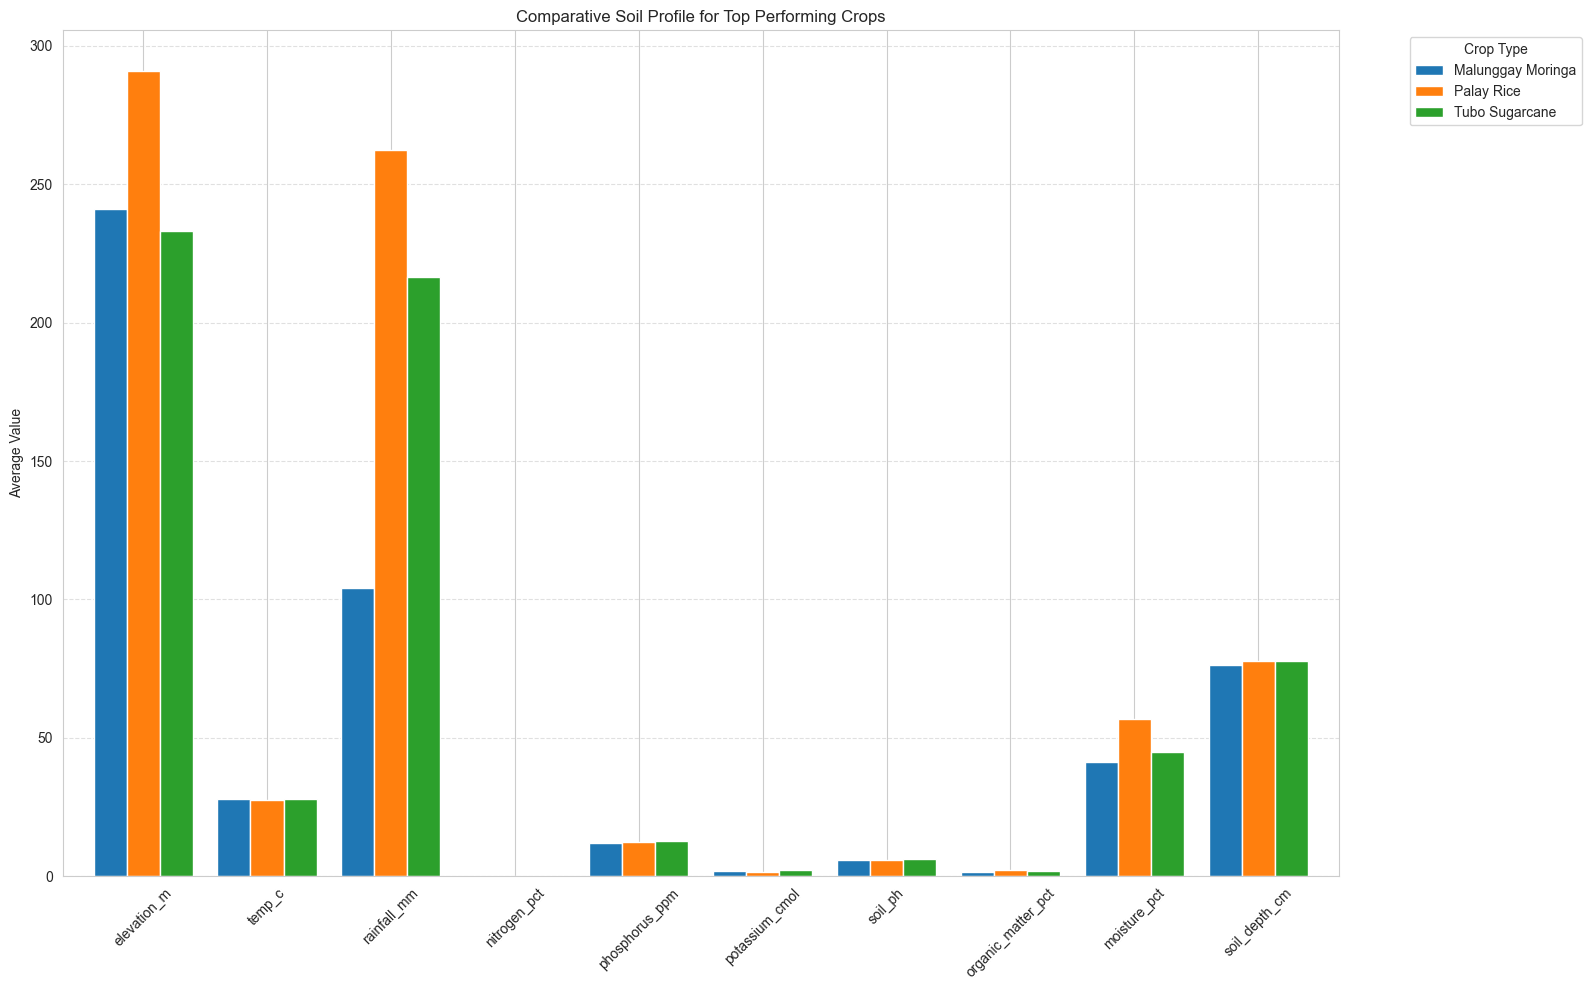

--- Mean Soil Profiles for Top Crops ---


best_crop,Malunggay Moringa,Palay Rice,Tubo Sugarcane
elevation_m,241.217726,291.031368,233.268701
temp_c,27.805780,27.497543,27.795379
rainfall_mm,104.160597,262.242097,216.477332
nitrogen_pct,0.146198,0.199493,0.203162
phosphorus_ppm,12.134080,12.396949,12.598017
potassium_cmol,1.809781,1.695175,2.107599
soil_ph,5.901445,5.883702,6.053531
organic_matter_pct,1.513449,2.085139,2.054760
moisture_pct,41.339981,56.701884,44.823627
soil_depth_cm,76.387283,77.813268,77.654752


In [15]:
# Identifying the top 3 crops by frequency
top_crops = df['best_crop'].value_counts().index[:3].tolist()

# Analyzing the mean feature profile for top crops
crop_profiles = df[df['best_crop'].isin(top_crops)].groupby('best_crop')[key_features].mean().T

# Visualization of Crop Profiles
plt.figure(figsize=(16, 10))
crop_profiles.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Comparative Soil Profile for Top Performing Crops')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'top_crop_profiles.png'))
plt.show()

# Statistical Summary of Profiles
print("--- Mean Soil Profiles for Top Crops ---")
display(crop_profiles)

### Final Synthesis and Summary
The Exploratory Data Analysis is now complete. We have transformed the raw data into a standardized format and uncovered the primary drivers of crop suitability.

**Summary of Findings:**
1. **Data Quality:** Missing values were successfully imputed, and text labels were standardized across all regions.
2. **Feature Distribution:** Key soil metrics (pH, Nitrogen, Phosphorus) follow distinct probability distributions, indicating varied soil types across the Philippines.
3. **Core Correlations:** Strong correlations were identified between organic matter and nutrient availability, confirming a logical biological link.
4. **Crop Profiles:** The top performing crops exhibit distinct "optimal" soil profiles, providing a target for predictive model development.

The dataset is now ready for Feature Engineering and Machine Learning modeling.

In [16]:
# Getting a summary of the data types and missing values
df.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 0 to 8029
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   sample_id                         8000 non-null   str    
 1   region                            8000 non-null   str    
 2   province_soil_name                8000 non-null   str    
 3   soil_texture_class                8000 non-null   str    
 4   climate_type                      8000 non-null   str    
 5   season                            8000 non-null   str    
 6   elevation_m                       8000 non-null   float64
 7   temp_c                            8000 non-null   float64
 8   rainfall_mm                       8000 non-null   float64
 9   nitrogen_pct                      8000 non-null   float64
 10  phosphorus_ppm                    8000 non-null   float64
 11  potassium_cmol                    8000 non-null   float64
 12  soil_ph               

### 🛠️ Step 2: The Tool Belt (Modular Approach)
Instead of writing the same code over and over, we'll build a "Tool Belt" 🧰. These are functions that we can use whenever we need to clean our data or draw a picture. 

**Analogy:** It's like having a specialized tool for every job—a hammer for nails and a screwdriver for screws. It keeps our work neat and organized!

In [17]:
class SoilDataToolbelt:
    """A set of tools for cleaning and analyzing soil data."""
    
    @staticmethod
    def clean_categorical(df, columns):
        """Cleans text data by removing weird symbols and fixing capitalization."""
        for col in columns:
            df[col] = df[col].str.replace(r'[^\w\s]', '', regex=True).str.strip().str.lower().str.title()
        return df

    @staticmethod
    def handle_missing_values(df, numerical_cols, categorical_cols):
        """Fills in the gaps! Numerical gets the middle value (median), Categorical gets the most common (mode)."""
        # Numerical imputation
        for col in numerical_cols:
            df[col] = df[col].fillna(df[col].median())
        
        # Categorical imputation
        for col in categorical_cols:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")
            
        return df

    @staticmethod
    def detect_outliers_iqr(series):
        """Finds 'The Odd Ones Out' using the IQR method."""
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        return lower_bound, upper_bound

    @staticmethod
    def plot_distribution(df, column, filename):
        """Draws a picture of how the data is spread out."""
        plt.figure(figsize=(10, 6))
        sns.histplot(df[column], kde=True, color='forestgreen')
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.savefig(os.path.join(FIG_DIR, filename))
        plt.close()

    @staticmethod
    def plot_correlation_matrix(df, columns):
        """Shows who likes to hang out with whom (Correlation)."""
        plt.figure(figsize=(12, 10))
        corr = df[columns].corr()
        sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
        plt.title('Soil Properties Correlation Heatmap')
        plt.savefig(os.path.join(FIG_DIR, 'soil_correlation_heatmap.png'))
        plt.close()

    @staticmethod
    def plot_crop_suitability(df, crop_col, score_cols):
        """Compares how different crops like the soil."""
        # This is a more complex plot - we'll handle it in a separate method or cell
        pass

print("🧰 Toolbelt is ready for action!")

🧰 Toolbelt is ready for action!


### 🧹 Step 3: Spring Cleaning (Data Cleaning)
Before we can trust our data, we need to clean it. 

**Analogy:** Imagine you have a bucket of LEGOs, but some pieces are dusty, some are broken, and a few are actually pieces of a different set. We need to:
1. **Dust it off:** Clean up the text (Categorical cleaning).
2. **Fill the gaps:** If a piece is missing, we find the most likely replacement (Imputation).
3. **Remove the "Odd Ones":** If we find a piece that is 10 times bigger than the others, it might be a mistake (Outlier handling).
4. **Tidy up labels:** Make sure "Wet Season" and "Wet" mean the same thing.

In [18]:
# 1. Identify column types
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Dust it off: Clean categorical text
df = SoilDataToolbelt.clean_categorical(df, categorical_cols)

# 3. Tidy up labels: Fix "Season" inconsistency
# We'll group 'Wet', 'Rainy', 'Wet Season', 'Rainy Season' into 'Wet Season'
# and 'Dry', 'Dry Season' into 'Dry Season'
season_map = {
    'Wet': 'Wet Season', 'Rainy': 'Wet Season', 'Rainy Season': 'Wet Season',
    'Dry': 'Dry Season', 'Dry Season': 'Dry Season'
}
df['season'] = df['season'].replace(season_map)

# 4. Fill the gaps: Handle missing values
df = SoilDataToolbelt.handle_missing_values(df, numerical_cols, categorical_cols)

# 5. Remove duplicates
df = df.drop_duplicates()

print("✨ Data is now sparkling clean!")
df.isna().sum().sum() # Should be 0 now


✨ Data is now sparkling clean!


np.int64(0)

### 🔍 Step 4: The Deep Dive (Intensive EDA)
Now that our data is clean, we can start our deep investigation. We aren't just looking at numbers; we're looking for *patterns*.

**Analogy:** This is like using a magnifying glass to look at the soil. We want to see:
1. **The Shape of the Data:** Is most of the soil acidic? Or is it all over the place? (Distributions).
2. **The Secret Friendships:** When Nitrogen goes up, does Phosphorus also go up? (Correlations).
3. **The Champions:** Which crops are the absolute winners, and what "secret recipe" of soil do they like? (Target Analysis).

In [19]:
# 1. Visualizing the 'Shape' of Soil Properties
# We'll pick the most important soil features to visualize
key_features = ['elevation_m', 'temp_c', 'rainfall_mm', 'nitrogen_pct', 'phosphorus_ppm', 
                'potassium_cmol', 'soil_ph', 'organic_matter_pct', 'moisture_pct', 'soil_depth_cm']

print("📈 Plotting distributions... Please wait.")
for feature in key_features:
    SoilDataToolbelt.plot_distribution(df, feature, f'dist_{feature}.png')

print("✅ Distributions saved to figures folder!")

📈 Plotting distributions... Please wait.
✅ Distributions saved to figures folder!


#### 🤝 Secret Friendships (Correlation)
Correlation tells us if two things move together. If Nitrogen and Organic Matter have a high correlation, it means they usually "travel in pairs".

**Analogy:** Like how ice cream sales and sunny days usually go up together. If one happens, the other probably does too!

In [20]:
# Plotting the correlation of soil properties
SoilDataToolbelt.plot_correlation_matrix(df, key_features)
print("✅ Correlation heatmap saved!")

✅ Correlation heatmap saved!


#### 🏆 The Champions (Best Crop Analysis)
We want to know which crops are the most common "winners" across the Philippines. This helps us see the most successful plants.

**Analogy:** This is like a leaderboard in a video game. We're checking who has the most gold medals!

C:\Users\pined\AppData\Local\Temp\ipykernel_5920\3151914983.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_counts.values, y=crop_counts.index, palette='viridis')


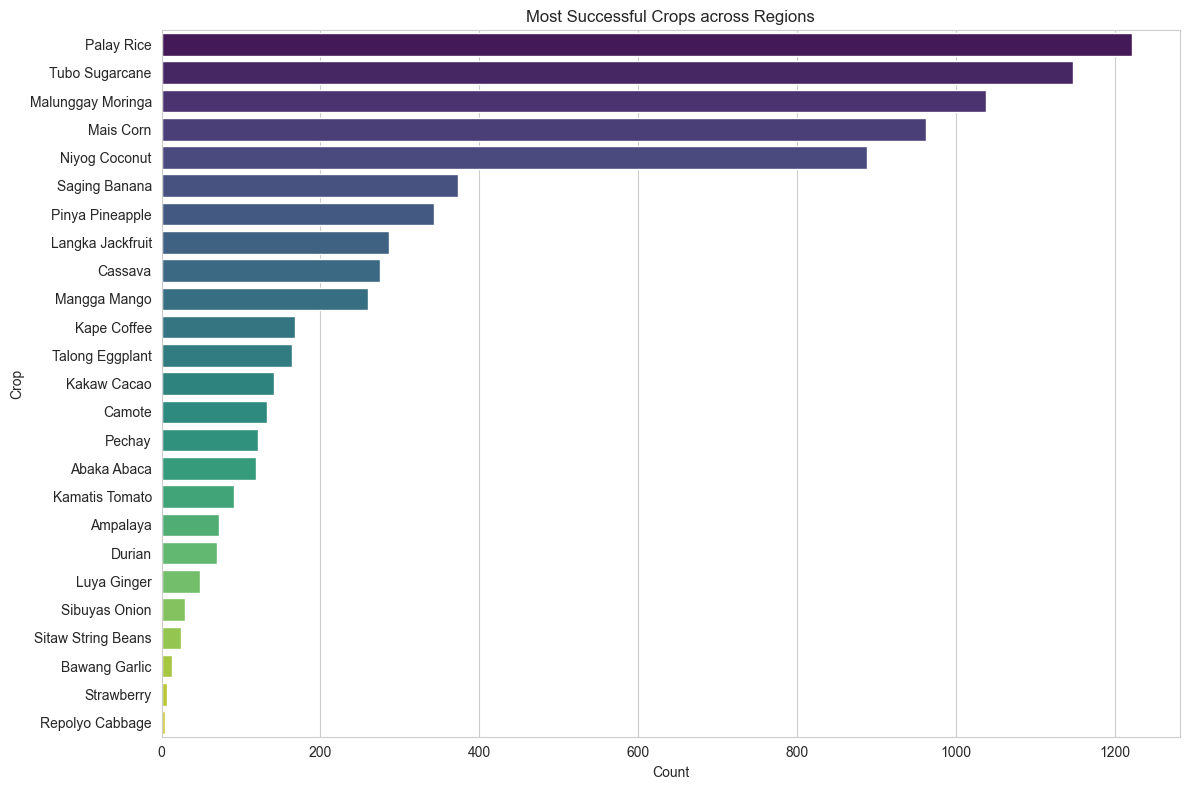

In [21]:
# Plotting best crop counts
crop_counts = df['best_crop'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=crop_counts.values, y=crop_counts.index, palette='viridis')
plt.title('Most Successful Crops across Regions')
plt.xlabel('Count')
plt.ylabel('Crop')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'best_crop_leaderboard.png'))
plt.show()

#### 🧪 The Secret Recipe (Soil Properties vs. Crops)
What makes a soil perfect for Rice but not for Coffee? We'll compare the average soil properties of the top 3 champion crops.

**Analogy:** If you want to bake the perfect cake, you need the right amount of sugar and flour. If you want to grow the perfect crop, you need the right amount of pH and Nitrogen!

Top 3 Champion Crops: ['Palay Rice', 'Tubo Sugarcane', 'Malunggay Moringa']


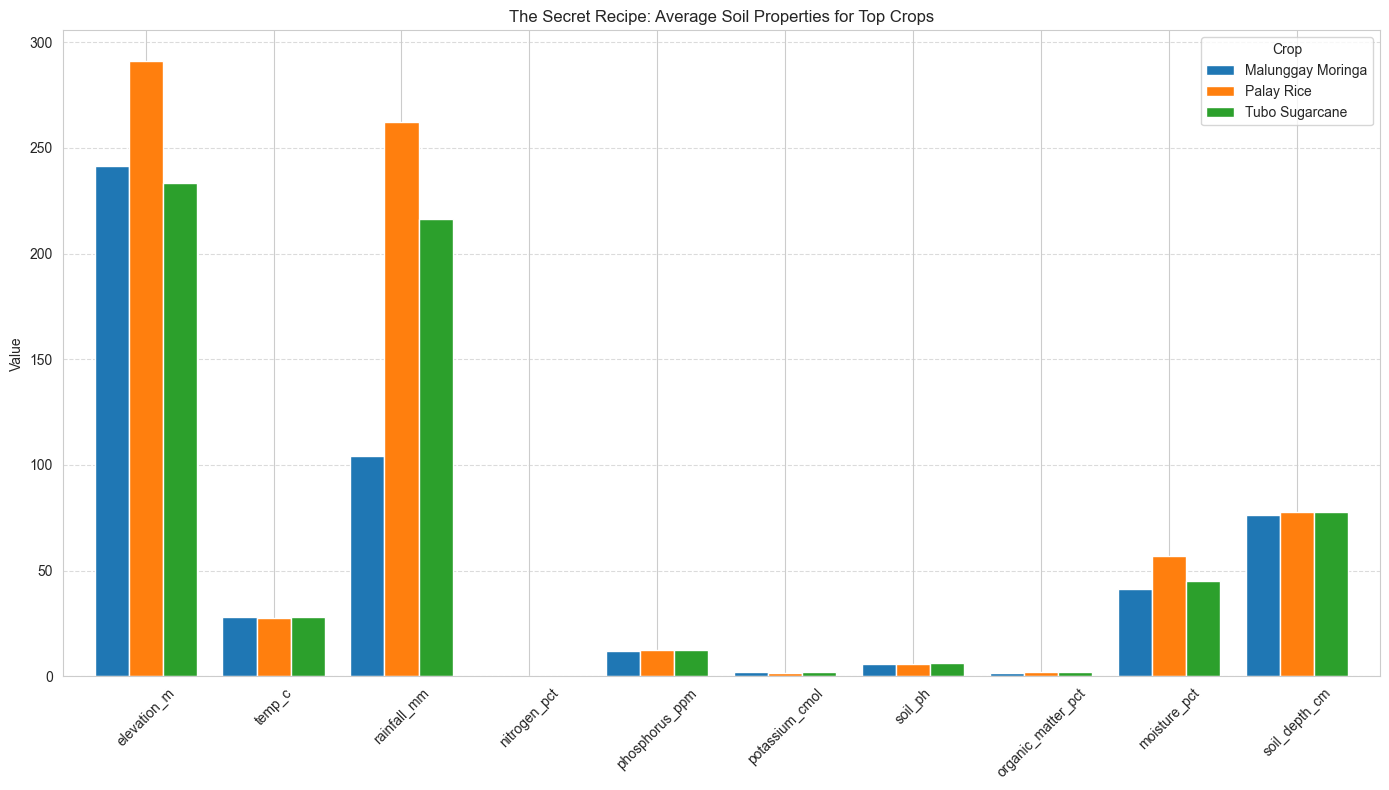

In [22]:
# Let's look at the top 3 crops
top_3 = df['best_crop'].value_counts().index[:3].tolist()
print(f"Top 3 Champion Crops: {top_3}")

# Compare their average key features
recipe_data = df[df['best_crop'].isin(top_3)].groupby('best_crop')[key_features].mean().T

# Plotting the comparison
recipe_data.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title('The Secret Recipe: Average Soil Properties for Top Crops')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(title='Crop')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'crop_secret_recipe.png'))
plt.show()

### 🏁 Conclusion: Case Closed!
We have finished our investigation! 🕵️‍♂️

**What did we learn?**
1. **Our Data is Ready:** We've cleaned the "dust" off our labels and filled in the missing pieces of our puzzle.
2. **The Patterns are Clear:** We can see how soil properties like pH and Nitrogen relate to each other.
3. **The Champions are Identified:** We know which crops are the most successful and what their "secret recipe" of soil is.

Now we can use this knowledge to build a model that helps farmers choose the best crop for their land! 🌾✨